Enter the average packet size (L) in bits : 1
Enter the bit rate (cost) for edge (1, 2): 2
Enter the bit rate (cost) for edge (1, 4): 1
Enter the bit rate (cost) for edge (2, 3): 3
Enter the bit rate (cost) for edge (2, 4): 2
Enter the bit rate (cost) for edge (2, 5): 5
Enter the bit rate (cost) for edge (3, 4): 3
Enter the bit rate (cost) for edge (3, 5): 1
Enter the bit rate (cost) for edge (3, 6): 5
Enter the bit rate (cost) for edge (4, 5): 1
Enter the bit rate (cost) for edge (5, 6): 2
Select the algorithm:
1: Dijkstra
2: Bellman-Ford
3: Both
Enter choice (1, 2 or 3): 3
Enter the starting node: 4

Running Dijkstra's Algorithm...

Dijkstra's Algorithm - Shortest paths from node 4:
Node 1: Distance = 1.0, Path = 4 -> 1
Node 2: Distance = 0.5, Path = 4 -> 2
Node 3: Distance = 0.3333333333333333, Path = 4 -> 3
Node 5: Distance = 0.7, Path = 4 -> 2 -> 5
Node 6: Distance = 0.5333333333333333, Path = 4 -> 3 -> 6

Running Bellman-Ford Algorithm...

Bellman-Ford Algorithm - Shortest paths 

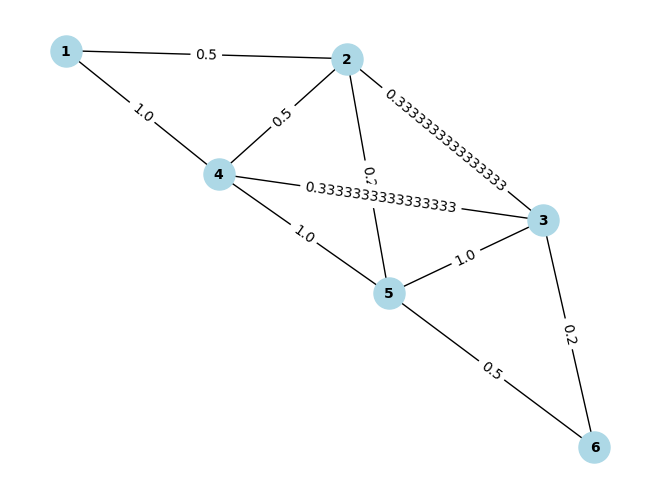


Dijkstra's Algorithm - Paths in a table:
   Node  Distance         Path
0     1  1.000000       4 -> 1
1     2  0.500000       4 -> 2
2     4  0.000000             
3     3  0.333333       4 -> 3
4     5  0.700000  4 -> 2 -> 5
5     6  0.533333  4 -> 3 -> 6

Bellman-Ford Algorithm - Paths in a table:
   Node  Distance         Path
0     1  1.000000       4 -> 1
1     2  0.500000       4 -> 2
2     4  0.000000             
3     3  0.333333       4 -> 3
4     5  0.700000  4 -> 2 -> 5
5     6  0.533333  4 -> 3 -> 6


In [ ]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Method for the calculation of the minimum cost using Dijkstra's method
def dijkstra(graph, start):
    queue = []  # Priority queue to store (distance, node) pairs
    heapq.heappush(queue, (0, start))  # Push the start node with distance 0
    distances = {node: float('inf') for node in graph}  # Initialize distances to all nodes as infinity
    distances[start] = 0  # Distance to the start node is 0
    predecessors = {node: None for node in graph}  # Initialize predecessors for path reconstruction

    while queue:
        current_distance, current_node = heapq.heappop(queue)  # Get the node with the smallest distance

        if current_distance > distances[current_node]:
            continue  # Skip if the current distance is greater than the known distance

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:  # If a shorter path is found
                distances[neighbor] = distance
                predecessors[neighbor] = current_node  # Update predecessor
                heapq.heappush(queue, (distance, neighbor))  # Push the neighbor to the queue

    return distances, predecessors

# Method for the calculation of the minimum cost using Bellman-Ford method
def bellman_ford(graph, start):
    distances = {node: float('inf') for node in graph}  # Initialize distances to all nodes as infinity
    distances[start] = 0  # Distance to the start node is 0
    predecessors = {node: None for node in graph}  # Initialize predecessors for path reconstruction

    # Relax all edges |V|-1 times
    for _ in range(len(graph) - 1):
        for node in graph:
            for neighbor, weight in graph[node].items():
                if distances[node] + weight < distances[neighbor]:  # If a shorter path is found
                    distances[neighbor] = distances[node] + weight
                    predecessors[neighbor] = node  # Update predecessor

    # Check for negative-weight cycles
    for node in graph:
        for neighbor, weight in graph[node].items():
            if distances[node] + weight < distances[neighbor]:
                raise ValueError("Graph contains a negative-weight cycle")

    return distances, predecessors

# Function to create a graph from a list of edges
def create_graph(edges):
    graph = {}
    for edge in edges:
        u, v, weight = edge
        if u not in graph:
            graph[u] = {}
        if v not in graph:
            graph[v] = {}
        graph[u][v] = weight
        graph[v][u] = weight  # If the graph is undirected
    return graph

# Function to draw the graph using NetworkX and Matplotlib
def draw_graph(edges):
    G = nx.Graph()
    G.add_weighted_edges_from(edges)
    pos = nx.spring_layout(G)  # Layout for positioning nodes
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()

# Function to print paths from the start node to all other nodes
def print_paths(predecessors, start):
    paths = {node: [] for node in predecessors}
    for node in predecessors:
        if node != start:
            current = node
            while current is not None:
                paths[node].insert(0, current)  # Reconstruct the path backwards
                current = predecessors[current]
    return paths

# Main function to run the program
def main():
    edges = [
        (1, 2), (1, 4), (2, 3), (2, 4), (2, 5),
        (3, 4), (3, 5), (3, 6), (4, 5), (5, 6)
    ]

    weighted_edges = []

    # Insert average packet size L
    while True:
        try:
            L = float(input("Enter the average packet size (L) in bits : "))
            if L <= 0:
                raise ValueError("The packet size must be a positive number")
            break
        except ValueError as e:
            print(f"Invalid input: {e}. Please enter a valid number.")

    # Insert costs for each edge
    for u, v in edges:
        while True:
            try:
                bit_rate = float(input(f"Enter the bit rate (cost) for edge ({u}, {v}): "))
                if bit_rate < 0:
                    raise ValueError("The bit rate must be a non-negative number.")
                weight = L / bit_rate  # Cost calculation
                weighted_edges.append((u, v, weight))
                break
            except ValueError as e:
                print(f"Invalid input: {e}. Please enter a valid number.")

    graph = create_graph(weighted_edges)

    # Choose which method user prefers
    while True:
        print("Select the algorithm:")
        print("1: Dijkstra")
        print("2: Bellman-Ford")
        print("3: Both")
        try:
            choice = int(input("Enter choice (1, 2 or 3): "))
            if choice not in [1, 2, 3]:
                raise ValueError("Choice must be 1, 2, or 3.")
            break
        except ValueError as e:
            print(f"Invalid input: {e}. Please enter 1, 2 or 3.")

    # Choose which node user wants to start with
    while True:
        try:
            start_node = int(input("Enter the starting node: "))
            if start_node not in graph:
                raise ValueError(f"Node {start_node} is not in the graph.")
            break
        except ValueError as e:
            print(f"Invalid input: {e}. Please enter a valid node number.")

    # Depending on the user's choice, run the selected algorithms
    if choice == 1 or choice == 3:
        print("\nRunning Dijkstra's Algorithm...")
        dijkstra_distances, dijkstra_predecessors = dijkstra(graph, start_node)
        dijkstra_paths = print_paths(dijkstra_predecessors, start_node)
        print(f"\nDijkstra's Algorithm - Shortest paths from node {start_node}:")
        for node, distance in dijkstra_distances.items():
            if node != start_node:
                print(f"Node {node}: Distance = {distance}, Path = {' -> '.join(map(str, dijkstra_paths[node]))}")

    if choice == 2 or choice == 3:
        print("\nRunning Bellman-Ford Algorithm...")
        bellman_ford_distances, bellman_ford_predecessors = bellman_ford(graph, start_node)
        bellman_ford_paths = print_paths(bellman_ford_predecessors, start_node)
        print(f"\nBellman-Ford Algorithm - Shortest paths from node {start_node}:")
        for node, distance in bellman_ford_distances.items():
            if node != start_node:
                print(f"Node {node}: Distance = {distance}, Path = {' -> '.join(map(str, bellman_ford_paths[node]))}")

    # Draw the graph
    draw_graph(weighted_edges)

    # Display the paths in a table for both algorithms if both were selected
    if choice == 3:
        print("\nDijkstra's Algorithm - Paths in a table:")
        dijkstra_df = pd.DataFrame([(node, dijkstra_distances[node], ' -> '.join(map(str, dijkstra_paths[node]))) for node in dijkstra_paths], columns=['Node', 'Distance', 'Path'])
        print(dijkstra_df)

        print("\nBellman-Ford Algorithm - Paths in a table:")
        bellman_ford_df = pd.DataFrame([(node, bellman_ford_distances[node], ' -> '.join(map(str, bellman_ford_paths[node]))) for node in bellman_ford_paths], columns=['Node', 'Distance', 'Path'])
        print(bellman_ford_df)

    elif choice == 1:
        print("\nDijkstra's Algorithm - Paths in a table:")
        dijkstra_df = pd.DataFrame([(node, dijkstra_distances[node], ' -> '.join(map(str, dijkstra_paths[node]))) for node in dijkstra_paths], columns=['Node', 'Distance', 'Path'])
        print(dijkstra_df)

    elif choice == 2:
        print("\nBellman-Ford Algorithm - Paths in a table:")
        bellman_ford_df = pd.DataFrame([(node, bellman_ford_distances[node], ' -> '.join(map(str, bellman_ford_paths[node]))) for node in bellman_ford_paths], columns=['Node', 'Distance', 'Path'])
        print(bellman_ford_df)

if __name__ == "__main__":
    main()
